# deps.dev

_Part of the **Decay Before Archival** project — see `README.md` for full project context, setup instructions, and links to the other notebooks (`deps_dev.ipynb`, `scorecard.ipynb`, `gh_archive.ipynb`, `pypi.ipynb`, `other_sources.ipynb`)._

In [ ]:
from google.cloud import bigquery
from decay_before_archival import get_client

client = get_client()

## Explore: deps.dev

deps.dev publishes package/dependency metadata as a public BigQuery dataset. We don't know the exact table names yet, so first list what's in the dataset, then peek columns on whichever table looks relevant before writing real queries.

**Planned analysis:** `PackageVersions`/`ProjectStatus` for release cadence and deprecation flags, `Dependents`/`DependencyGraphEdges` for how many projects rely on a package (blast radius), `Projects` for repo-level status deps.dev has already enriched.

In [ ]:
# List tables in the deps.dev public dataset
tables_query = """
SELECT table_name
FROM `bigquery-public-data.deps_dev_v1.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_run = client.query(tables_query, job_config=job_config)
print(f"This query will process {dry_run.total_bytes_processed / 1e6:.2f} MB")

client.query(tables_query).to_dataframe()

In [ ]:
# Pick a table name from the list above, then peek its columns and grab a small sample
table_name = "NPMRequirements"  # replace with a name from the list above

columns_query = f"""
SELECT column_name, data_type
FROM `bigquery-public-data.deps_dev_v1.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = '{table_name}'
ORDER BY ordinal_position
"""

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_run = client.query(columns_query, job_config=job_config)
print(f"This query will process {dry_run.total_bytes_processed / 1e6:.2f} MB")

client.query(columns_query).to_dataframe()

In [ ]:
sample_query = f"""
SELECT *
FROM `bigquery-public-data.deps_dev_v1.{table_name}`
LIMIT 10
"""

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_run = client.query(sample_query, job_config=job_config)
print(f"This query will process {dry_run.total_bytes_processed / 1e6:.2f} MB")

client.query(sample_query).to_dataframe()

## Coverage + features (two-year window)

Join key is `repo_full_name` (lowercased) ↔ `Projects.Name` / `PackageVersionToProject.ProjectName` (`Type = 'GITHUB'`).

- **Two snapshots:** `SNAP_END` = last weekly snapshot before the 2025-01-01 cutoff, `SNAP_START` = one year earlier. `Projects` stats (stars/forks/open issues) are taken at both so we can compute change. Release history comes from `PackageVersions` at `SNAP_END`, which already contains every version ever published (so 2023 and 2024 counts both come from one scan).
- **Don't use later snapshots for features.** `Deprecated` / `ProjectStatus` are empty until late 2025 — they're candidate *labels* (see the "Latest status" section), not features.
- Run order: setup cell → coverage → features → export. The dependents cell is opt-in (~420 GB scan).

In [ ]:
import pandas as pd

# Repos from the GH Archive feature set (label = inactive_next_365d, cutoff 2025-01-01).
# We match on LOWER() because GitHub names are case-insensitive.
repo_names = (
    pd.read_csv("../data/gh_archive_features_2024_clean.csv", usecols=["repo_full_name"])
    ["repo_full_name"].str.lower().unique().tolist()
)

# deps.dev snapshots are weekly. Pick the last one before the cutoff, and the last one a year earlier,
# so we can compute year-over-year change without looking past 2025-01-01 (no label leakage).
snap = next(iter(client.query("""
SELECT
  (SELECT MAX(Time) FROM `bigquery-public-data.deps_dev_v1.Snapshots` WHERE Time < TIMESTAMP('2025-01-01')) AS snap_end,
  (SELECT MAX(Time) FROM `bigquery-public-data.deps_dev_v1.Snapshots` WHERE Time < TIMESTAMP('2024-01-01')) AS snap_start
""").result()))
SNAP_END, SNAP_START = snap.snap_end, snap.snap_start
print(f"{len(repo_names):,} repos | snapshots: {SNAP_START} -> {SNAP_END}")


def run(sql, dry=False):
    """Run a query with the shared @repos / @snap_start / @snap_end params; dry=True just prints the scan size."""
    cfg = bigquery.QueryJobConfig(
        dry_run=dry,
        use_query_cache=not dry,
        query_parameters=[
            bigquery.ArrayQueryParameter("repos", "STRING", repo_names),
            bigquery.ScalarQueryParameter("snap_start", "TIMESTAMP", SNAP_START),
            bigquery.ScalarQueryParameter("snap_end", "TIMESTAMP", SNAP_END),
        ],
    )
    job = client.query(sql, job_config=cfg)
    if dry:
        print(f"This query will process {job.total_bytes_processed / 1e9:.2f} GB")
        return None
    return job.to_dataframe()

In [ ]:
COVERAGE = """
WITH p AS (
  SELECT SnapshotAt, LOWER(Name) AS repo
  FROM `bigquery-public-data.deps_dev_v1.Projects`
  WHERE SnapshotAt IN (@snap_start, @snap_end) AND Type = 'GITHUB' AND LOWER(Name) IN UNNEST(@repos)
),
pk AS (
  SELECT DISTINCT LOWER(ProjectName) AS repo
  FROM `bigquery-public-data.deps_dev_v1.PackageVersionToProject`
  WHERE SnapshotAt = @snap_end AND ProjectType = 'GITHUB' AND RelationType = 'SOURCE_REPO_TYPE'
    AND LOWER(ProjectName) IN UNNEST(@repos)
)
SELECT
  ARRAY_LENGTH(@repos) AS repos_total,
  (SELECT COUNT(*) FROM p WHERE SnapshotAt = @snap_end)   AS in_projects_end,
  (SELECT COUNT(*) FROM p WHERE SnapshotAt = @snap_start) AS in_projects_start,
  (SELECT COUNT(*) FROM p a JOIN p b USING (repo) WHERE a.SnapshotAt = @snap_end AND b.SnapshotAt = @snap_start) AS in_projects_both,
  (SELECT COUNT(*) FROM pk) AS with_published_package
"""

run(COVERAGE, dry=True)
run(COVERAGE).T

In [ ]:
FEATURES = """
WITH
proj AS (
  SELECT LOWER(Name) AS repo,
    MAX(IF(SnapshotAt = @snap_end,   StarsCount, NULL))      AS stars_end,
    MAX(IF(SnapshotAt = @snap_start, StarsCount, NULL))      AS stars_start,
    MAX(IF(SnapshotAt = @snap_end,   ForksCount, NULL))      AS forks_end,
    MAX(IF(SnapshotAt = @snap_start, ForksCount, NULL))      AS forks_start,
    MAX(IF(SnapshotAt = @snap_end,   OpenIssuesCount, NULL)) AS open_issues_end,
    MAX(IF(SnapshotAt = @snap_start, OpenIssuesCount, NULL)) AS open_issues_start
  FROM `bigquery-public-data.deps_dev_v1.Projects`
  WHERE SnapshotAt IN (@snap_start, @snap_end) AND Type = 'GITHUB' AND LOWER(Name) IN UNNEST(@repos)
  GROUP BY repo
),
pkg AS (
  SELECT LOWER(ProjectName) AS repo, System, Name, Version
  FROM `bigquery-public-data.deps_dev_v1.PackageVersionToProject`
  WHERE SnapshotAt = @snap_end AND ProjectType = 'GITHUB' AND RelationType = 'SOURCE_REPO_TYPE'
    AND LOWER(ProjectName) IN UNNEST(@repos)
),
base AS (  -- every repo deps.dev knows about, via Projects OR a package link (some have packages but no Projects row)
  SELECT repo FROM proj
  UNION DISTINCT
  SELECT repo FROM pkg
),
rel AS (
  SELECT k.repo, k.System, k.Name, v.UpstreamPublishedAt AS published_at,
         ARRAY_LENGTH(v.Advisories) AS n_advisories
  FROM pkg k
  JOIN `bigquery-public-data.deps_dev_v1.PackageVersions` v
    ON v.System = k.System AND v.Name = k.Name AND v.Version = k.Version
  WHERE v.SnapshotAt = @snap_end
)
SELECT
  b.repo,
  ANY_VALUE(p.repo IS NOT NULL)                                                   AS in_projects,
  p.stars_end, p.stars_start, p.forks_end, p.forks_start, p.open_issues_end, p.open_issues_start,
  COUNT(DISTINCT CONCAT(r.System, '/', r.Name))                                   AS n_packages,
  COUNT(DISTINCT r.System)                                                        AS n_ecosystems,
  COUNT(r.published_at)                                                           AS n_versions_total,
  COUNTIF(r.published_at >= TIMESTAMP('2024-01-01') AND r.published_at < TIMESTAMP('2025-01-01')) AS versions_2024,
  COUNTIF(r.published_at >= TIMESTAMP('2023-01-01') AND r.published_at < TIMESTAMP('2024-01-01')) AS versions_2023,
  DATE_DIFF(DATE '2025-01-01', DATE(MAX(r.published_at)), DAY)                    AS days_since_last_version_at_cutoff,
  SUM(r.n_advisories)                                                             AS advisory_links
FROM base b
LEFT JOIN proj p ON p.repo = b.repo
LEFT JOIN rel r ON r.repo = b.repo
GROUP BY b.repo, p.stars_end, p.stars_start, p.forks_end, p.forks_start, p.open_issues_end, p.open_issues_start
"""

run(FEATURES, dry=True)
deps_features = run(FEATURES)
deps_features.head()

In [ ]:
# Export for the integration notebook. One row per GH Archive repo that deps.dev knows about (join on repo_full_name_lower).
# Repos missing from this file are NOT in deps.dev -> report them as missing in the integration step.
deps_features.rename(columns={"repo": "repo_full_name_lower"}).to_csv("../data/deps_dev_features_2024.csv", index=False)
print(f"wrote {len(deps_features):,} rows")

## Latest status (label candidate — NOT a feature)

`Deprecated` / `ProjectStatus` are empty in 2024 snapshots, so we read them from the **latest** snapshot and keep them in a separate file. Use them only as an alternative outcome label, never as inputs for the 2025 cutoff. (Test run: 0 of the matched repos are `archived`, ~65 have a deprecated package.)

In [ ]:
SNAP_LATEST = next(iter(client.query("SELECT MAX(Time) AS t FROM `bigquery-public-data.deps_dev_v1.Snapshots`").result())).t

STATUS = """
WITH pkg AS (
  SELECT LOWER(ProjectName) AS repo, System, Name, Version
  FROM `bigquery-public-data.deps_dev_v1.PackageVersionToProject`
  WHERE SnapshotAt = @snap_latest AND ProjectType = 'GITHUB' AND RelationType = 'SOURCE_REPO_TYPE'
    AND LOWER(ProjectName) IN UNNEST(@repos)
)
SELECT k.repo,
  COUNT(*)                                 AS n_versions_latest,
  LOGICAL_OR(v.ProjectStatus = 'archived') AS any_archived,
  LOGICAL_OR(v.Deprecated IS NOT NULL)     AS any_deprecated,
  LOGICAL_AND(v.Deprecated IS NOT NULL)    AS all_deprecated
FROM pkg k
JOIN `bigquery-public-data.deps_dev_v1.PackageVersions` v
  ON v.System = k.System AND v.Name = k.Name AND v.Version = k.Version
WHERE v.SnapshotAt = @snap_latest
GROUP BY k.repo
"""

status_cfg = lambda dry: bigquery.QueryJobConfig(dry_run=dry, query_parameters=[
    bigquery.ArrayQueryParameter("repos", "STRING", repo_names),
    bigquery.ScalarQueryParameter("snap_latest", "TIMESTAMP", SNAP_LATEST),
])
job = client.query(STATUS, job_config=status_cfg(True))
print(f"This query will process {job.total_bytes_processed / 1e9:.2f} GB")  # ~32 GB

status_df = client.query(STATUS, job_config=status_cfg(False)).to_dataframe()
status_df.rename(columns={"repo": "repo_full_name_lower"}).to_csv("../data/deps_dev_status_latest.csv", index=False)
print(f"wrote {len(status_df):,} rows")
status_df[["any_archived", "any_deprecated", "all_deprecated"]].sum()

In [ ]:
# OPTIONAL / EXPENSIVE: direct-dependent counts (blast radius), rolled up to repo level, at the end snapshot.
# Dependents is huge (~420 GB scanned, ~40% of the 1 TB monthly free tier), so this is off by default.
RUN_DEPENDENTS = False

DEPENDENTS = """
WITH pkg AS (
  SELECT DISTINCT LOWER(ProjectName) AS repo, System, Name
  FROM `bigquery-public-data.deps_dev_v1.PackageVersionToProject`
  WHERE SnapshotAt = @snap_end AND ProjectType = 'GITHUB' AND RelationType = 'SOURCE_REPO_TYPE'
    AND LOWER(ProjectName) IN UNNEST(@repos)
)
SELECT pkg.repo,
       COUNT(DISTINCT CONCAT(d.Dependent.System, '/', d.Dependent.Name)) AS direct_dependents
FROM `bigquery-public-data.deps_dev_v1.Dependents` d
JOIN pkg USING (System, Name)
WHERE d.SnapshotAt = @snap_end AND d.MinimumDepth = 1
GROUP BY pkg.repo
"""

run(DEPENDENTS, dry=True)
if RUN_DEPENDENTS:
    dependents_df = run(DEPENDENTS)
    dependents_df.rename(columns={"repo": "repo_full_name_lower"}).to_csv("../data/deps_dev_dependents_2024.csv", index=False)
    print(f"wrote {len(dependents_df):,} rows")

**Notes:**

_(add observations here)_

## Which deps.dev tables we use (and why not the rest)

The proposal needs these variables: release cadence / time since last release, community signals (stars, forks), **number of projects that depend on this project**, and advisories as a health signal. deps.dev is only one source for that list; commits, bus factor, contributor turnover and issue/PR responsiveness come from GH Archive / the GitHub API, and Criticality Score + per-check scores come from OpenSSF Scorecard.

| Table | Decision | Why |
|---|---|---|
| `Projects` | **Used** | stars / forks / open issues at two snapshots (community engagement, year-over-year change) |
| `PackageVersionToProject` | **Used** | the only repo -> package link (the join to GitHub repos) |
| `PackageVersions` | **Used** | release cadence, time since last release, advisory links |
| `Snapshots` | **Used** | pick snapshots before the 2025-01-01 cutoff (no label leakage) |
| `Dependents` | **In scope, deferred** | "number of dependent projects" is in the proposal, but it scans ~420 GB (~40% of the monthly free tier). Opt-in cell below; run once we know which repos we keep |
| `Advisories` | Skipped | advisory data is planned from OSV.dev; `advisory_links` from `PackageVersions` is enough for a first pass |
| `Dependencies`, `DependencyGraphEdges` | Skipped | a package's own dependency tree isn't a proposal variable, and they scan 224 GB / 494 GB per snapshot |
| `*Requirements` (npm, PyPI, Maven, ...) | Skipped | per-ecosystem declared requirements; not a decay signal and only covers one ecosystem each |
| `PackageVersionHashes` | Skipped | file hashes, unrelated to project health |
| `*Latest` tables | **Never for features** | they reflect today's state, which would leak the 2025 outcome. Only the latest-status cell uses a recent snapshot, and only as a label candidate |

**Coverage caveat:** deps.dev only knows repos linked to a published package, so only ~2% of the GH Archive repos match. That's the "coverage gaps between data sources" the proposal says to be explicit about.

**Notes:**

- **Coverage:** deps.dev knows 1,405 of the 62,627 GH Archive rows (2.2%): 951 have a published package and 454 are listed with no package. Matching is on the lowercased repo name; renamed or recreated repos can silently fail to match.
- **Package-only repos:** 165 repos have a package link but no `Projects` row at the 2024-12-30 snapshot. They're kept (`in_projects = False`) with release data but `stars_*`, `forks_*` and `open_issues_*` are missing.
- **Missing `_start` columns:** 854 matched repos have no `*_start` values (the 165 above plus 689 repos that weren't in deps.dev a year earlier). That's structural, not random — don't impute or treat as zero.
- **Missing release dates:** `days_since_last_version_at_cutoff` is missing for 655 matched repos, but only 454 have no package, so roughly 201 repos with packages have no publish timestamp. **Verified:** 197 of those 201 repos publish only to Go (the other 4 are Maven / NuGet), consistent with Go modules not recording `UpstreamPublishedAt` (checked with the package-name file from `package_registries.ipynb`). Until checked, `versions_2023` / `versions_2024` are probably undercounts for those repos.
- **Not features:** `Deprecated` / `ProjectStatus` are empty before late 2025. In the latest snapshot none of the matched repos is `archived` and about 65 have a deprecated package, so `archived` is not usable as a label here.
- **Skipped on purpose:** see the table-decision section above. `Dependents` is in scope for the proposal but deferred (~420 GB).

## Visualizations & preprocessing (report section)

Everything below reads the exported CSVs, so it runs without BigQuery. It covers the preprocessing items from the report assignment for the deps.dev source: missing values, descriptive statistics, histograms / scatter plots / tables, and normalization.

Reminder: the file has one row per GH Archive repo that deps.dev knows about (1,405 of 62,627), so these plots describe the **matched** repos only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

FIG_DIR = Path("../figures")

def save_svg(fig, name):
    """Write a figure to figures/ as SVG (no timestamp, so re-runs give clean diffs)."""
    fig.savefig(FIG_DIR / name, bbox_inches="tight", metadata={"Date": None})

feat = pd.read_csv("../data/deps_dev_features_2024.csv")
status = pd.read_csv("../data/deps_dev_status_latest.csv")
feat["has_package"] = feat["n_packages"] > 0
num_cols = [c for c in feat.columns if c not in ("repo_full_name_lower", "in_projects", "has_package")]
print(f"{len(feat):,} repos x {len(num_cols)} numeric variables")

1,405 repos x 13 numeric variables


### 0. Cleaning and validation

**Assignment item:** Data Preprocessing → *clean the data so that it can be processed.*

The exported files come straight from BigQuery, so cleaning here means checking the invariants the rest of the notebook relies on and fixing the few things that would break the merge. Each check below should report 0 violations; anything else is a data problem to fix before moving on.

In [2]:
# Key hygiene and internal-consistency checks on the features file (each count should be 0).
key = feat["repo_full_name_lower"]
checks = {
    "duplicate repo keys": key.duplicated().sum(),
    "keys not lowercase / with stray whitespace": (key != key.str.lower().str.strip()).sum(),
    "keys that are not owner/name": (~key.str.contains("/")).sum(),
    "negative counts": (feat[num_cols] < 0).sum().sum(),
    "n_ecosystems > n_packages": (feat["n_ecosystems"] > feat["n_packages"]).sum(),
    "versions_2023 + versions_2024 > n_versions_total": (feat["versions_2023"] + feat["versions_2024"] > feat["n_versions_total"]).sum(),
    "in_projects disagrees with stars_end being present": (feat["in_projects"] != feat["stars_end"].notna()).sum(),
    "*_start present for a repo not in Projects": ((~feat["in_projects"]) & feat["stars_start"].notna()).sum(),
    "advisory_links present for a repo with no package": ((~feat["has_package"]) & feat["advisory_links"].notna()).sum(),
    "advisory_links missing for a repo with a package": (feat["has_package"] & feat["advisory_links"].isna()).sum(),
}
pd.Series(checks, name="violations").to_frame()

,violations
duplicate repo keys,0
keys not lowercase / with stray whitespace,0
keys that are not owner/name,0
negative counts,0
n_ecosystems > n_packages,0
versions_2023 + versions_2024 > n_versions_total,0
in_projects disagrees with stars_end being present,0
*_start present for a repo not in Projects,0
advisory_links present for a repo with no package,0
advisory_links missing for a repo with a package,0


**Notes (cleaning, features file):** all ten checks report 0 violations: keys are unique, lowercase and `owner/name`, no negative counts, and the flag columns agree with the data (`in_projects` ⇔ `stars_end` present, `advisory_links` present ⇔ the repo has a package). The one anomaly isn't a violation: 201 repos have a package but no publish timestamp (documented in the missingness notes). Nothing was dropped or altered, so the exported CSV is used as-is.

In [3]:
# The latest-status file needs real cleaning before it can be merged.
print(f"status file: {len(status):,} rows | dtypes: any_archived={status['any_archived'].dtype}")

# 1. any_archived is an object column that is NaN when deps.dev has no ProjectStatus: make that explicit instead of NaN-as-False.
status["any_archived"] = status["any_archived"].astype("boolean")

# 2. The latest snapshot includes repos that were not in the 2024 features file (packages first published after the cutoff).
#    They must not enter the merge, so keep only repos that exist in the cutoff-time features file.
in_feat = status["repo_full_name_lower"].isin(feat["repo_full_name_lower"])
print(f"status rows not in the 2024 features file (dropped): {(~in_feat).sum():,}")
print(f"features repos with no status row (kept, status = missing): {(~feat['repo_full_name_lower'].isin(status['repo_full_name_lower'])).sum():,}")
status = status[in_feat].reset_index(drop=True)

# 3. any_archived is missing for most repos (deps.dev rarely sets ProjectStatus), so it is not usable as a label.
print(f"\nmatched status rows: {len(status):,} | any_archived missing: {status['any_archived'].isna().sum():,} | False: {(status['any_archived'] == False).sum():,} | True: {(status['any_archived'] == True).sum():,}")
status.dtypes.to_frame("dtype").T

status file: 1,186 rows | dtypes: any_archived=object
status rows not in the 2024 features file (dropped): 155
features repos with no status row (kept, status = missing): 374

matched status rows: 1,031 | any_archived missing: 839 | False: 192 | True: 0


,repo_full_name_lower,n_versions_latest,any_archived,any_deprecated,all_deprecated
dtype,str,int64,boolean,bool,bool


**Notes (cleaning, latest-status file):**

- **Dropped 155 rows** that exist in the latest snapshot but not in the 2024 features file (packages first published after the cutoff). Merging them would add repos that didn't exist at the cutoff, so they are excluded. 374 features repos have no status row; they keep missing status after the merge.
- **`any_archived` is mostly missing:** 839 of 1,031 matched rows (81%) have no `ProjectStatus`, 192 are `False` and none are `True`. NaN means "deps.dev didn't record a status", not "not archived", so it was converted from an object column to a nullable boolean. It can't serve as the label.
- **Features file:** no changes were needed.

### 1. Missing values per variable

Missingness here is structural (see the notes above), so we split it by *why* the value is missing: repo not in `Projects` at the snapshot, repo not in `Projects` a year earlier, no package, or package without a publish timestamp.

,missing,pct
stars_start,854,60.8
forks_start,854,60.8
open_issues_start,854,60.8
days_since_last_version_at_cutoff,655,46.6
advisory_links,454,32.3
stars_end,165,11.7
forks_end,165,11.7
open_issues_end,165,11.7
n_packages,0,0.0
n_ecosystems,0,0.0


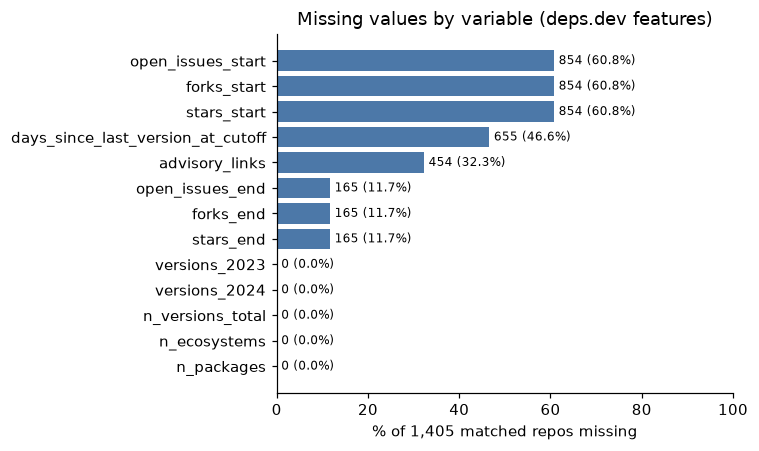

In [4]:
miss = pd.DataFrame({"missing": feat[num_cols].isna().sum()})
miss["pct"] = (100 * miss["missing"] / len(feat)).round(1)
miss = miss.sort_values("missing", ascending=True)
display(miss.sort_values("missing", ascending=False))

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.barh(miss.index, miss["pct"], color="#4C78A8")
ax.bar_label(bars, labels=[f"{m:,} ({p}%)" for m, p in zip(miss["missing"], miss["pct"])], padding=3, fontsize=8)
ax.set_xlabel("% of 1,405 matched repos missing")
ax.set_xlim(0, 100)
ax.set_title("Missing values by variable (deps.dev features)")
plt.tight_layout(); save_svg(fig, "depsdev_missing_values.svg"); plt.show()

**Assignment item:** Data Preprocessing → *frequency of missing values of each variable.*

**What it shows:** share of the 1,405 matched repos missing each variable. The five release/popularity count columns are complete (0%). The `*_start` columns are the worst at 60.8% (854 repos), then `days_since_last_version_at_cutoff` at 46.6% (655), `advisory_links` at 32.3% (454) and the `*_end` columns at 11.7% (165). The three `stars` / `forks` / `open_issues` columns always go missing together, which points to one cause (repo absent from `Projects`) rather than three.

In [5]:
# Why are they missing? Cross-tab each group of columns against the structural flags.
reason = pd.DataFrame([
    ("stars/forks/open_issues _end", feat["stars_end"].isna().sum(), "not in Projects at the end snapshot (in_projects = False)", (~feat["in_projects"]).sum()),
    ("stars/forks/open_issues _start", feat["stars_start"].isna().sum(), "not in Projects at end snapshot", (~feat["in_projects"]).sum()),
    ("", None, "in Projects at end but not a year earlier", (feat["in_projects"] & feat["stars_start"].isna()).sum()),
    ("advisory_links", feat["advisory_links"].isna().sum(), "no package (has_package = False)", (~feat["has_package"]).sum()),
    ("days_since_last_version_at_cutoff", feat["days_since_last_version_at_cutoff"].isna().sum(), "no package", (~feat["has_package"]).sum()),
    ("", None, "has package but no publish timestamp", (feat["has_package"] & feat["days_since_last_version_at_cutoff"].isna()).sum()),
], columns=["variable", "rows missing", "reason", "rows"])
reason.fillna({"rows missing": ""}).set_index("variable")

,rows missing,reason,rows
variable,,,
stars/forks/open_issues _end,165.0,not in Projects at the end snapshot (in_projec...,165
stars/forks/open_issues _start,854.0,not in Projects at end snapshot,165
,,in Projects at end but not a year earlier,689
advisory_links,454.0,no package (has_package = False),454
days_since_last_version_at_cutoff,655.0,no package,454
,,has package but no publish timestamp,201


**Assignment item:** Data Preprocessing → *understand why values are missing and decide how to deal with it.*

**What it shows:** each missing group traced to a cause. All 165 missing `*_end` values are repos with no `Projects` row at the end snapshot. Of the 854 missing `*_start` values, 165 are those same repos and 689 were first listed after the start snapshot. All 454 missing `advisory_links` are repos with no package. For `days_since_last_version_at_cutoff`, 454 are explained by no package, but 201 packaged repos have no publish timestamp (unexplained). **Decision:** keep as `NaN` and use `in_projects` / `has_package` as indicators; don't impute zeros.

### 2. Descriptive statistics

In [6]:
desc = feat[num_cols].describe(percentiles=[.25, .5, .75, .95]).T
desc["skew"] = feat[num_cols].skew()
desc.round(2)

,count,mean,std,min,25%,50%,75%,95%,max,skew
stars_end,1240.0,302.11,1805.60,0.0,0.0,1.0,17.25,1071.85,35707.0,11.69
stars_start,551.0,520.01,2238.12,0.0,1.0,6.0,94.50,2465.00,27167.0,7.58
forks_end,1240.0,50.25,306.36,0.0,0.0,0.0,4.00,164.45,6468.0,12.69
forks_start,551.0,92.77,395.90,0.0,0.0,2.0,23.00,358.00,5736.0,8.62
open_issues_end,1240.0,10.49,45.98,0.0,0.0,0.0,3.00,50.00,983.0,11.22
open_issues_start,551.0,18.93,63.74,0.0,0.0,1.0,9.00,93.00,963.0,8.32
n_packages,1405.0,3.40,61.64,0.0,0.0,1.0,1.00,4.00,2278.0,35.95
n_ecosystems,1405.0,0.70,0.51,0.0,0.0,1.0,1.00,1.00,4.0,-0.02
n_versions_total,1405.0,20.07,119.70,0.0,0.0,1.0,8.00,57.00,2776.0,14.92
versions_2024,1405.0,8.35,77.33,0.0,0.0,0.0,3.00,19.00,2198.0,23.33


**Assignment item:** Data Preprocessing → *descriptive statistics of each variable.*

**What it shows:** count, mean, spread, percentiles and skew for every numeric variable. Means sit far above medians, which signals heavy right skew: stars has a median of 1 but a mean of ~302 and a max of 35,707, and the 95th percentile is ~1,072. `days_since_last_version_at_cutoff` has a median of 121.5 days but a max of 3,256 (about nine years). `n_packages` reaches 2,278 for a single repo against a mean of 3.4. Skew values of 7–36 on the counts motivate the log transform in section 5.

In [7]:
# Categorical / boolean variables as tables
cat = pd.concat({
    "in_projects": feat["in_projects"].value_counts().rename(index=str),
    "has_package": feat["has_package"].value_counts().rename(index=str),
    "n_ecosystems": feat["n_ecosystems"].value_counts().sort_index().rename(index=str),
    "any_deprecated (latest)": status["any_deprecated"].value_counts(dropna=False).rename(index=str),
}, names=["variable", "value"]).rename("repos").to_frame()
cat["pct"] = (100 * cat["repos"] / cat.groupby(level=0)["repos"].transform("sum")).round(1)
cat

repos   pct
variable                value             
in_projects             True    1240  88.3
                        False    165  11.7
has_package             True     951  67.7
                        False    454  32.3
n_ecosystems            0        454  32.3
                        1        928  66.0
                        2         18   1.3
                        3          4   0.3
                        4          1   0.1
any_deprecated (latest) False    968  93.9
                        True      63   6.1

**Assignment item:** Data Preprocessing → *descriptive statistics for categorical variables (tables).*

**What it shows:** counts and percentages for the categorical / boolean variables. 88.3% of matched repos have a `Projects` row and 67.7% have a published package. 66% publish to exactly one ecosystem and only 23 repos (1.6%) to two or more. Of the 1,031 matched repos with a latest-status row, 6.1% (63) have a deprecated package.

### 3. Distributions (histograms)

These counts are heavily right-skewed (median stars is 1, max is ~36k), so the raw histograms are mostly one tall bar. The log₁₀(x+1) view in the second row is the one to read.

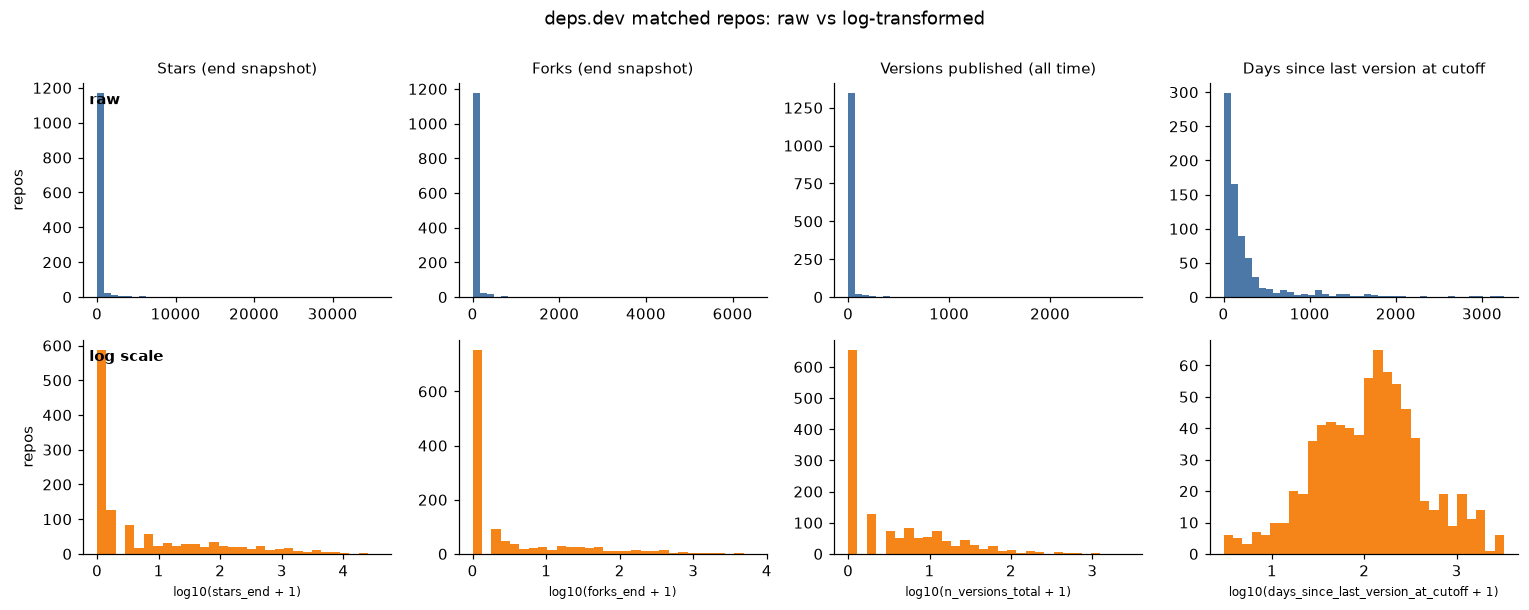

In [8]:
hist_vars = {
    "stars_end": "Stars (end snapshot)",
    "forks_end": "Forks (end snapshot)",
    "n_versions_total": "Versions published (all time)",
    "days_since_last_version_at_cutoff": "Days since last version at cutoff",
}
fig, axes = plt.subplots(2, len(hist_vars), figsize=(14, 5.5))
for j, (col, label) in enumerate(hist_vars.items()):
    x = feat[col].dropna()
    axes[0, j].hist(x, bins=40, color="#4C78A8")
    axes[0, j].set_title(label, fontsize=10)
    axes[1, j].hist(np.log10(x + 1), bins=30, color="#F58518")
    axes[1, j].set_xlabel(f"log10({col} + 1)", fontsize=8)
    axes[0, j].set_ylabel("repos" if j == 0 else "")
    axes[1, j].set_ylabel("repos" if j == 0 else "")
axes[0, 0].annotate("raw", (0.02, 0.9), xycoords="axes fraction", weight="bold")
axes[1, 0].annotate("log scale", (0.02, 0.9), xycoords="axes fraction", weight="bold")
fig.suptitle("deps.dev matched repos: raw vs log-transformed", y=1.0)
plt.tight_layout(); save_svg(fig, "depsdev_hist_raw_vs_log.svg"); plt.show()

**Assignment item:** Data Preprocessing → *visualize key variables as histograms*, plus *normalization and transformation* (the raw vs log rows).

**What it shows:** the top row (raw) is a single tall bar at zero for stars, forks and versions because of the long tail. The bottom row (log₁₀) reveals the shape: about 590 repos have 0 stars and 750 have 0 forks (a spike at 0), with a long spread across 1 to ~30k stars. Versions published also spike at 0 (655 repos with none). Days since last version is roughly bell-shaped on the log scale, centred around 100–200 days, with a tail of repos untouched for years.

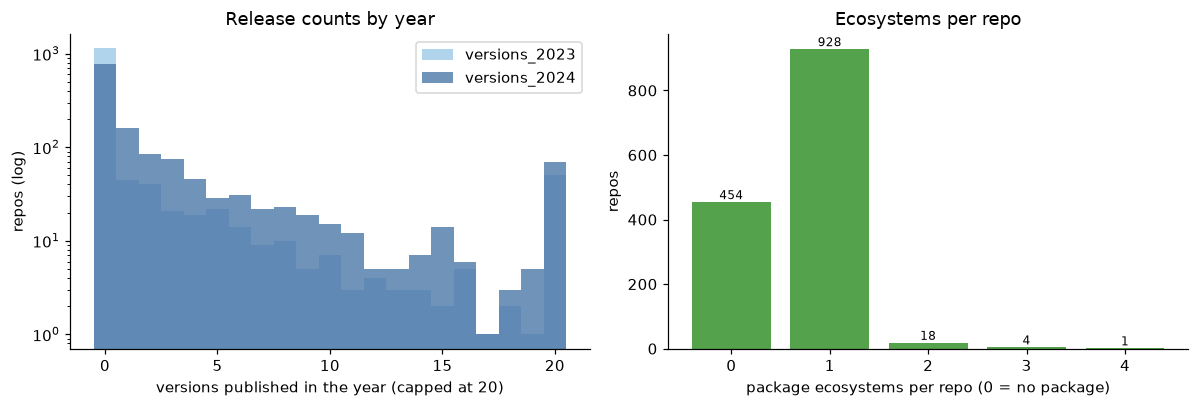

In [9]:
# Release activity: how many repos published anything, and how does 2024 compare to 2023?
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
cap = 20
for col, color in [("versions_2023", "#9ecae9"), ("versions_2024", "#4C78A8")]:
    axes[0].hist(feat[col].clip(upper=cap), bins=np.arange(0, cap + 2) - 0.5, alpha=0.8, label=col, color=color)
axes[0].set_yscale("log"); axes[0].set_xlabel(f"versions published in the year (capped at {cap})"); axes[0].set_ylabel("repos (log)")
axes[0].legend(); axes[0].set_title("Release counts by year")

eco = feat["n_ecosystems"].value_counts().sort_index()
axes[1].bar(eco.index.astype(str), eco.values, color="#54A24B")
for i, v in enumerate(eco.values): axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
axes[1].set_xlabel("package ecosystems per repo (0 = no package)"); axes[1].set_ylabel("repos"); axes[1].set_title("Ecosystems per repo")
plt.tight_layout(); save_svg(fig, "depsdev_release_activity.svg"); plt.show()

**Assignment item:** Data Preprocessing → *visualize key variables as histograms and tables* (release cadence is the project's main decay signal).

**What it shows:** left, the number of versions each repo published in 2023 vs 2024 (log y-axis, capped at 20). 1,138 repos published nothing in 2023 and 773 published nothing in 2024, so more repos were releasing in 2024; 69 repos published 20+ versions in 2024 (51 in 2023). Right, ecosystems per repo: 454 repos have none, 928 have one and only 23 have two or more.

### 4. Relationships (scatter plots)

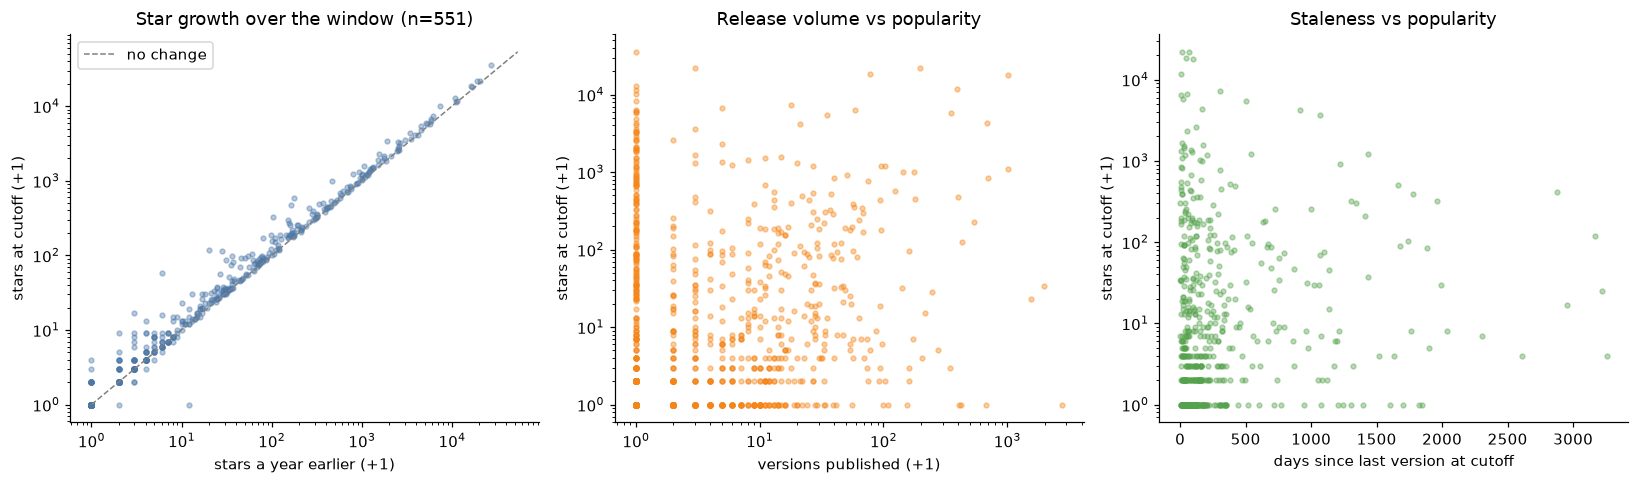

In [10]:
both = feat.dropna(subset=["stars_start", "stars_end"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(both["stars_start"] + 1, both["stars_end"] + 1, s=10, alpha=0.4, color="#4C78A8")
lim = [1, both[["stars_start", "stars_end"]].max().max() * 1.5]
ax.plot(lim, lim, color="grey", ls="--", lw=1, label="no change")
ax.set(xscale="log", yscale="log", xlabel="stars a year earlier (+1)", ylabel="stars at cutoff (+1)",
       title=f"Star growth over the window (n={len(both):,})")
ax.legend()

ax = axes[1]
ax.scatter(feat["n_versions_total"] + 1, feat["stars_end"] + 1, s=10, alpha=0.4, color="#F58518")
ax.set(xscale="log", yscale="log", xlabel="versions published (+1)", ylabel="stars at cutoff (+1)",
       title="Release volume vs popularity")

ax = axes[2]
rel = feat.dropna(subset=["days_since_last_version_at_cutoff", "stars_end"])
ax.scatter(rel["days_since_last_version_at_cutoff"], rel["stars_end"] + 1, s=10, alpha=0.4, color="#54A24B")
ax.set(yscale="log", xlabel="days since last version at cutoff", ylabel="stars at cutoff (+1)",
       title="Staleness vs popularity")
plt.tight_layout(); save_svg(fig, "depsdev_scatter_relationships.svg"); plt.show()

**Assignment item:** Data Preprocessing → *visualize key variables as scatter plots.*

**What it shows:**
- **Star growth (left, 551 repos with both snapshots):** points hug the dashed no-change line. 304 repos gained stars, 230 were unchanged and 17 lost stars. Gains are visible mostly for small repos, where a few stars is a large relative change.
- **Release volume vs popularity (middle):** a wide cloud with no clear trend. Many highly starred repos have only one version, and some repos with hundreds of versions have few stars.
- **Staleness vs popularity (right):** no clear relationship. Repos untouched for over a year (118 of 750) span the full range of star counts, so popularity alone doesn't protect against release decay.

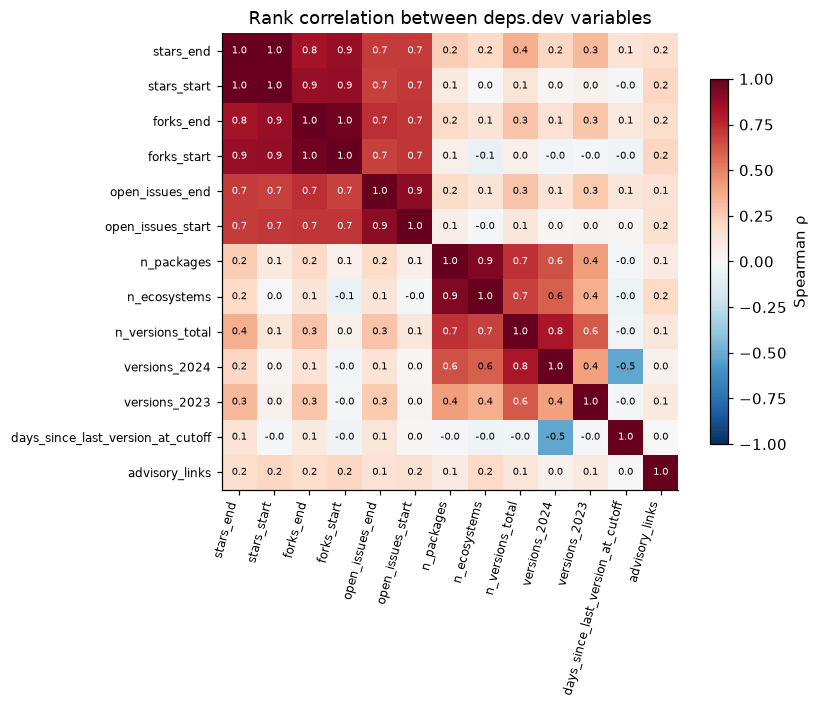

In [11]:
# Correlation of the (log-transformed) numeric variables
logged = np.log1p(feat[num_cols])
corr = logged.corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=75, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if pd.notna(v): ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6.5, color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Rank correlation between deps.dev variables")
plt.tight_layout(); save_svg(fig, "depsdev_corr_spearman.svg"); plt.show()

**Assignment item:** Data Preprocessing → *descriptive statistics / relationships between variables* (also guides which binary features to build for pattern mining).

**What it shows:** Spearman correlation on log-transformed values. Two clear blocks: stars / forks / open issues correlate strongly with each other (0.7–1.0), and packages / ecosystems / versions correlate strongly with each other (0.6–0.9). Between the two blocks the link is weak (about 0.0–0.4), consistent with the scatter plots. `days_since_last_version_at_cutoff` vs `versions_2024` is −0.5, which is partly mechanical (a repo with releases in 2024 can't be more than 365 days stale). Within a block the variables are redundant; keep one per block for modelling.

### 5. Normalization and transformation

Counts are log-transformed (`log1p`) to tame the skew, then z-scored so variables share a scale for distance-based methods. Missing values are left as `NaN` — they are structural, so impute only after the sources are merged and the model type is known. The indicator columns (`in_projects`, `has_package`) carry the missingness signal.

In [12]:
count_cols = ["stars_end", "forks_end", "open_issues_end", "n_packages", "n_versions_total",
              "versions_2024", "versions_2023", "days_since_last_version_at_cutoff", "advisory_links"]
log_df = np.log1p(feat[count_cols])
z_df = (log_df - log_df.mean()) / log_df.std()
z_df.columns = [f"{c}_logz" for c in count_cols]

skew = pd.DataFrame({"skew_raw": feat[count_cols].skew(), "skew_log1p": log_df.skew(), "skew_log1p_z": z_df.skew().set_axis(count_cols)}).round(2)
display(skew)
z_df.describe().T[["count", "mean", "std", "min", "max"]].round(2)

,skew_raw,skew_log1p,skew_log1p_z
stars_end,11.69,1.40,1.40
forks_end,12.69,1.78,1.78
open_issues_end,11.22,1.66,1.66
n_packages,35.95,3.28,3.28
n_versions_total,14.92,1.25,1.25
versions_2024,23.33,1.78,1.78
versions_2023,12.67,2.99,2.99
days_since_last_version_at_cutoff,3.57,-0.05,-0.05
advisory_links,25.88,11.37,11.37


,count,mean,std,min,max
stars_end_logz,1240.0,-0.0,1.0,-0.72,3.68
forks_end_logz,1240.0,0.0,1.0,-0.61,4.34
open_issues_end_logz,1240.0,0.0,1.0,-0.63,4.45
n_packages_logz,1405.0,0.0,1.0,-0.94,11.24
n_versions_total_logz,1405.0,-0.0,1.0,-0.81,4.50
versions_2024_logz,1405.0,-0.0,1.0,-0.69,6.06
versions_2023_logz,1405.0,0.0,1.0,-0.40,6.17
days_since_last_version_at_cutoff_logz,750.0,-0.0,1.0,-2.72,2.52
advisory_links_logz,951.0,-0.0,1.0,-0.09,15.32


**Assignment item:** Data Preprocessing → *perform normalization and transformation as necessary.*

**What it shows:** skew before and after `log1p`, then after z-scoring. Skew drops from 11.7 to 1.4 (stars), 12.7 to 1.8 (forks), 14.9 to 1.3 (versions) and 3.6 to −0.05 (days since last version), so the transform worked for most columns. `advisory_links` stays highly skewed (25.9 to 11.4) because most packaged repos have zero advisories; treat it as a binary (has any advisory) instead. The z-scored columns have mean 0 and std 1; z-scoring doesn't change skew, only scale.

### 6. Latest deprecation status vs 2024 activity

deps.dev's `Deprecated` flag is the closest thing this source has to an outcome (a label *candidate*, never a feature: it is only populated in late-2025 snapshots). This section asks whether repos whose package was later deprecated looked different in 2024. Only the repos present in both files are used.

any_deprecated
not deprecated    968
deprecated         63


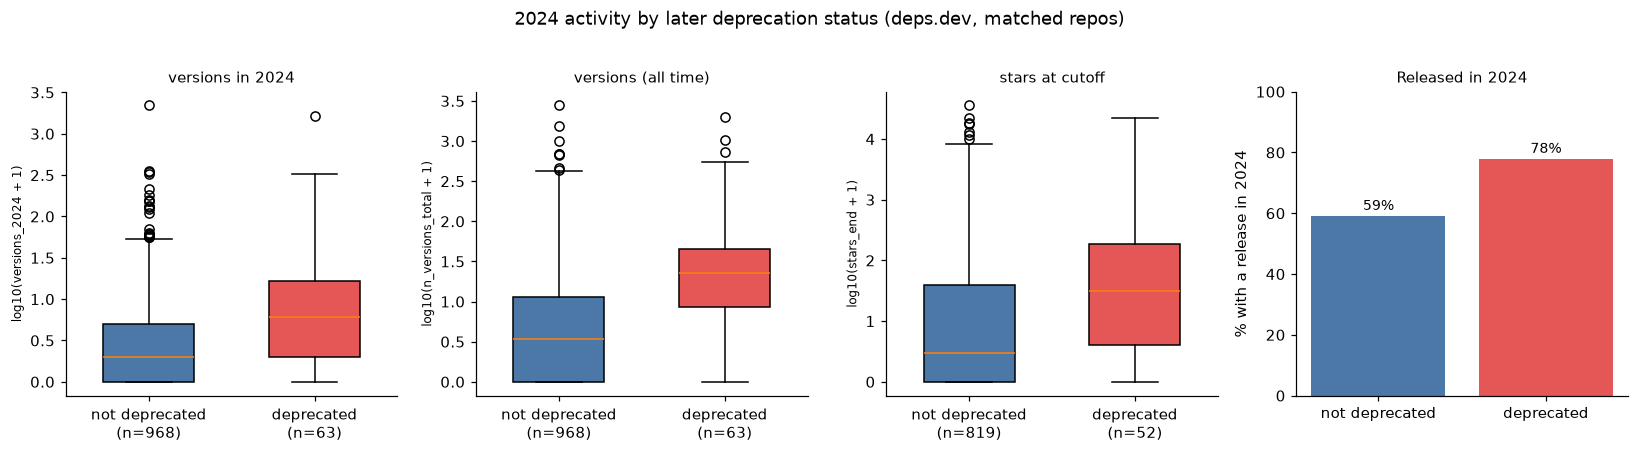

In [13]:
m = feat.merge(status, on="repo_full_name_lower", how="inner")
grp = m["any_deprecated"].map({False: "not deprecated", True: "deprecated"})
counts = grp.value_counts()
print(counts.to_string())

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
order = ["not deprecated", "deprecated"]
colors = {"not deprecated": "#4C78A8", "deprecated": "#E45756"}
for ax, (col, label) in zip(axes[:3], [("versions_2024", "versions in 2024"), ("n_versions_total", "versions (all time)"), ("stars_end", "stars at cutoff")]):
    data = [np.log10(m.loc[grp == g, col].dropna() + 1) for g in order]
    bp = ax.boxplot(data, tick_labels=[f"{g}\n(n={len(d)})" for g, d in zip(order, data)], patch_artist=True, widths=0.55)
    for patch, g in zip(bp["boxes"], order): patch.set_facecolor(colors[g])
    ax.set_ylabel(f"log10({col} + 1)", fontsize=8); ax.set_title(label, fontsize=10)

rate = m.groupby(grp)["versions_2024"].apply(lambda s: 100 * (s > 0).mean()).reindex(order)
bars = axes[3].bar(order, rate.values, color=[colors[g] for g in order])
axes[3].bar_label(bars, labels=[f"{v:.0f}%" for v in rate.values], padding=2, fontsize=9)
axes[3].set_ylim(0, 100); axes[3].set_ylabel("% with a release in 2024"); axes[3].set_title("Released in 2024", fontsize=10)
plt.suptitle("2024 activity by later deprecation status (deps.dev, matched repos)", y=1.02)
plt.tight_layout(); save_svg(fig, "depsdev_deprecation_vs_activity.svg"); plt.show()

**Assignment item:** Data Preprocessing → *visualize key variables* (using the one outcome-like variable deps.dev has).

**What it shows:** repos whose package was later flagged deprecated (n=63) versus those that weren't (n=968), compared on 2024 activity. The deprecated group looks *more* active, not less: median versions in 2024 is higher, they have more versions overall (middle-left box), more stars, and 78% released something in 2024 versus 59%. So deprecation in deps.dev tracks package maturity (older, more-released packages are the ones that get superseded), not abandonment, which is why it is a poor decay label. Caveat: only 63 deprecated repos and the stars box uses 52 of them, so treat the gap as indicative.

**Notes (visualizations):**

- **Missingness is structural, not random.** 165 repos (11.7%) have no `Projects` row at the end snapshot, which accounts for every missing `*_end` value. Of the 854 missing `*_start` values, 165 are those same repos and 689 are repos first listed after the start snapshot. 454 repos have no package, which accounts for all missing `advisory_links`. 201 packaged repos still have no publish timestamp (197 of them are Go-only repos; see above).
- **Everything is heavily right-skewed.** Median stars is 1 and the max is ~36k, so the raw histograms are one bar. `log1p` cuts skew from 12-36 to 1-3 for most count variables; `advisory_links` stays skewed (11.4) because 95% of packaged repos have zero advisories. `days_since_last_version_at_cutoff` becomes roughly bell-shaped on a log scale.
- **Stars barely moved over the year.** Repos sit close to the no-change line on the star-growth scatter; growth shows up mostly in small repos (a few stars gained is a large relative change).
- **Release volume and popularity are only loosely related** (middle scatter), and many popular repos have a single version.
- **Sample caveat:** 67.7% of matched repos have a package and 6.1% of the 1,031 matched repos with a latest-status row have a deprecated package. These plots describe the 2.2% of GH Archive repos that deps.dev knows about, which skews toward published, more mature projects.

**Notes (why the matched set is small):**

- **Ceiling:** the features query only looks up repos already in the GH Archive set, so it can never return more than 62,627 rows. It returned 1,405 (2.2%).
- **Coverage, not a bug:** deps.dev lists repos tied to a published package, and the GH Archive sample is mostly tiny repos (`stars_received_2024`: median 0, 90th percentile 0, 99th percentile 12), so few publish a package.
- **Renames are not the cause:** for the 3,000 unmatched repos with the most 2024 stars (median 2), we searched `Projects` at the cutoff snapshot for the same repo name under a different owner (~204 MB scanned). The 361 repos that matched were forks or personal copies (e.g. `deeptesh-rout/tensorflow` -> `tensorflow/tensorflow`, many `*/dotfiles`), not renamed repos, so fuzzy matching would add wrong data. The exact lowercase name join stays.
- **Not tested:** `Projects` has no repo id column, so an id-based join wasn't possible, and only the highest-star unmatched repos were checked.
- **Implication:** a larger deps.dev set needs a different base sample (start from packaged repos, or filter GH Archive by minimum activity), which is a team decision. The same sampling mismatch is why the 10,330-repo GitHub API pool overlaps GH Archive on only 15 repos.